<a href="https://colab.research.google.com/github/Ymin-2/ESAA/blob/main/ESAA_OB_WEEK10_1_TS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **7. 시계열 분석**

## **7.1 시계열 분석**

시계열 분석: 시간에 따라 변하는 데이터를 사용하여 추이를 분석하는 것  
추세를 파악하거나 향후 전망 등을 예측하기 위한 용도로 시계열 분석 사용

시계열 형태
- 불규칙 변동: 시계열 자료에서 시간에 따른 규칙적인 움직임과 달리 어떤 규칙성이 없어 예측 불가능하고 우연적으로 발생하는 변동
- 추세 변동: 시계열 자료가 갖는 장기적인 변화 추세
- 순환 변동: 대체로 2~3년 정도의 일정한 기간을 주기로 순환적으로 나타나는 변동
- 계절 변동: 시계열 자료에서 보통 계절적 영향과 사회적 관습에 따라 1년 주기로 발생하는 것

- 규칙적 시계열: 트렌드와 분산이 불변하는 데이터
- 불규칙적 시계열: 트렌드 혹은 분산이 변화하는 시계열 데이터

## **7.2 AR, MA, ARMA, ARIMA**

### **7.2.1 AR 모델**

AR(자기 회귀) 모델: 이전 관측 값이 이후 관측 값에 영향을 준다는 아이디어에 대한 모형
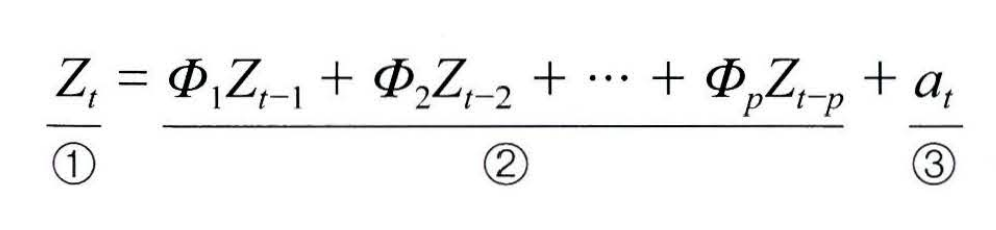

1. 시계열 데이터에서 현재 시점
2. 과거가 현재에 미치는 영향을 나타내는 모수(Ø)에 시계열 데이터의 과거 시점을 곱한 것
3. 시계열 분석에서 오차 항을 의미하며 백색 잡음이라고도 함

수식은 p 시점을 기준으로 그 이전의 데이터에 의해 현재 시점의 데이터가 영향을 받는 모형이라고 할 수 있음

### **7.2.2 MA 모델**

MA(이동 평균) 모델: 트렌드가 변화하는 상황에 적합한 회귀 모델  
시계열을 따라 윈도우 크기만큼 슬라이딩된다고 해서 이동 평균 모델이라고 함
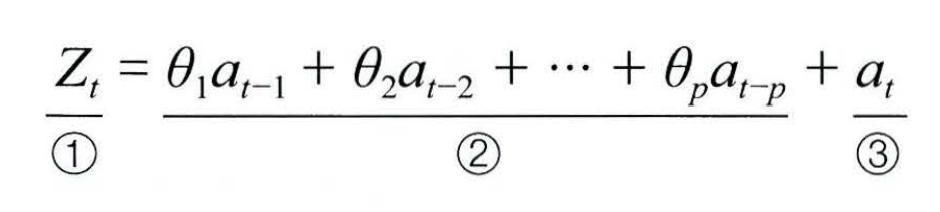

1. 시계열 데이터에서 현재 시점
2. 매개변수(θ)에 과거 시점의 오차를 곱한 것
3. 오차 항

수식은 현재 데이터의 상태를 추론하는 것이 아닌, 이전 데이터의 오차에서 현재 데이터의 상태를 추론

### **7.2.3 ARMA 모델**

ARMA(자기 회귀 이동 평균) 모델: AR과 MA를 섞은 모델, 연구 기관에서 주로 사용
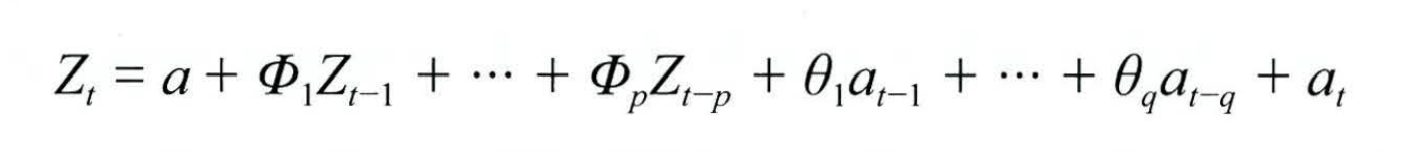

### **7.2.4 ARIMA 모델**

ARIMA(자기 회귀 누적 이동 평균) 모델: 자기 회귀와 이동 평균을 둘 다 고려하는 모형

선형 관계 뿐맡 ㅏ니라 추세까지 고려한 모델

statsmodels 라이브러리를 이용하여 ARIMA 모델 구현 절차
1. ARIMA() 함수를 호출하여 사용, ARIMA(p, d, q)
  - p: 자기 회귀 차수
  - d: 차분 차수
  - q: 이동 평균 차수
2. fit() 메서드를 호출하고 모델에 데이터를 적용해 훈련시킴
3. predict() 메서드를 호출해 미래의 추세 및 동향에 대해 예측

In [ ]:
!pip install statsmodels

In [ ]:
!git clone https://github.com/gilbutITbook/080289.git

fatal: destination path '080289' already exists and is not an empty directory.


/tmp/ipykernel_24112/3411653765.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = read_csv('/content/080289/chap07/data/sales.csv', header=0, parse_dates=[0],
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Sun, 03 May 2026   AIC                            411.302
Time:                        13:31:05   BIC                            420.634
Sample:                    01-01-1991   HQIC                           414.523
                         - 12-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8788      0.227     -3.876      0.000      -1.323      -0.434
ar.L2         -0.2787      0.232     -1.203      0.229      -0.733       0.176
ar.L3         -0.0076      0.270     -0.028      0.9

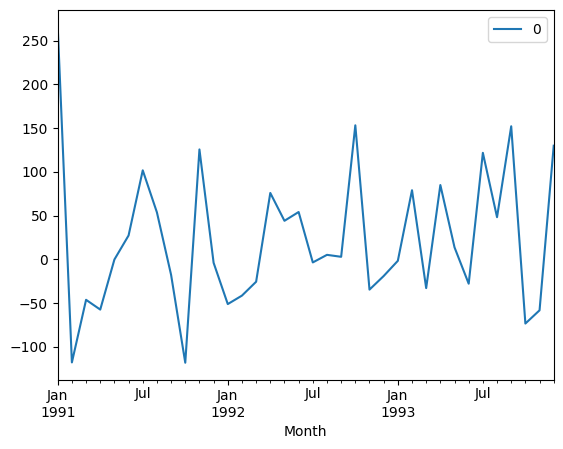

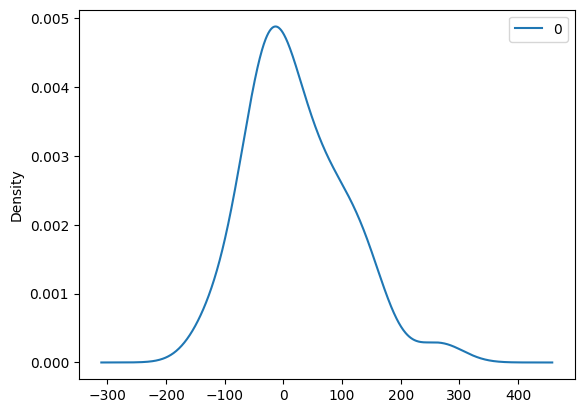

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [ ]:
# 7-1 ARIMA() 함수를 호출해 sales 데이터셋에 대한 예측
from pandas import read_csv
from datetime import datetime
from pandas import DataFrame
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

# 시간을 표현하는 함수 정의
def parser(x):
  return datetime.strptime('199'+x, '%Y-%m') # strptime()은 날짜와 시간 정보를 문자열로 바꾸어 주는 메서드

series = read_csv('/content/080289/chap07/data/sales.csv', header=0, parse_dates=[0],
                  index_col=0, date_parser=parser) # 자전거 매출에 대한 CSV 데이터 호출
model = ARIMA(series, order=(5, 1, 0)) # ARIMA() 함수 호출
model_fit = model.fit()
print(model_fit.summary()) # 모델에 대한 정보 표시
residuals = DataFrame(model_fit.resid) # DataFrame에 모델에 대한 오차 정보를 residuals라는 변수에 저장
residuals.plot() # residuals 정보를 시각적으로 표현
pyplot.show()
residuals.plot(kind = 'kde')
pyplot.show()
print(residuals.describe())

값이 치우쳐 있음 (오류 평균이 0이 아님)

/tmp/ipykernel_24112/1402240296.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = read_csv('/content/080289/chap07/data/sales.csv', header=0, parse_dates=[0],
/tmp/ipykernel_24112/1402240296.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f, expected=%f' % (yhat, obs)) # 모델 실행 결과를 predicted로 출력하고, test로 분리해 둔 데이터를 expected로 사용해 출력


predicted=352.855343, expected=346.300000
predicted=277.398036, expected=329.700000
predicted=368.753734, expected=445.400000
predicted=331.773635, expected=325.900000
predicted=372.070407, expected=449.300000
predicted=360.020872, expected=411.300000
predicted=454.526230, expected=417.400000
predicted=388.690699, expected=545.500000
predicted=437.632447, expected=477.600000
predicted=516.437624, expected=687.000000
predicted=520.916191, expected=435.300000
predicted=675.594647, expected=587.300000
predicted=505.201016, expected=676.900000
Test MSE: 9118.818


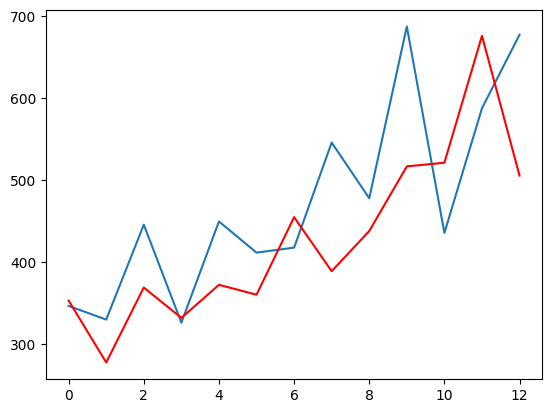

In [ ]:
## 7-2 statsmodels 라이브러리를 이용한 sales 데이터셋 예측
import numpy as np
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def parser(x):
  return datetime.strptime('199'+x, '%Y-%m')

series = read_csv('/content/080289/chap07/data/sales.csv', header=0, parse_dates=[0],
                  index_col=0, date_parser=parser)
X = series.values
X = np.nan_to_num(X)
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)] # train과 test로 데이터셋 분리
history = [x for x in train]
predictions = list()
for t in range(len(test)): # test 데이터셋의 길이(13)만큼 반복해 수행
  model = ARIMA(history, order=(5, 1, 0)) # ARIMA() 함수 호출
  model_fit = model.fit()
  output = model_fit.forecast() # forecast() 메서드를 사용해 예측 수행
  yhat = output[0] # 모델 출력 결과를 yhat에 저장
  predictions.append(yhat)
  obs = test[t]
  history.append(obs)
  print('predicted=%f, expected=%f' % (yhat, obs)) # 모델 실행 결과를 predicted로 출력하고, test로 분리해 둔 데이터를 expected로 사용해 출력
error = mean_squared_error(test, predictions) # 손실 함수로 평균 제곱 오차 사용
print('Test MSE: %.3f' % error)
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

## **7.3 순환 신경망(RNN)**

RNN: 시간적으로 연속성이 있는 데이터를 처리하려고 고안된 인공 신경망

새로운 입력이 네트워크로 들어올 때마다 기억은 조금씩 수정됨, 최종적으로 남겨진 기억은 모든 입력 전체를 요약한 정보가 됨

1. 일대일: 순환이 없기 때문에 RNN이라고 말하기 어려우며, 순방향 네트워크가 대표적 사례
2. 일대다: 입력이 하나이고, 출력이 다수인 구조. 이미지를 입력해 이미지에 대한 설명을 문장으로 출력하는 이미지 캡션이 대표적 사례
3. 다대일: 입력이 다수이고 출력이 하나인 구조, 문장을 입력해 긍/부정을 출력하는 감성 분석기에서 사용
4. 다대다: 입력과 출력이 다수인 구조, 언어를 번역하는 자동 번역기 등이 대표적 사례
5. 동기화 다대다: 다대다의 유형처럼 입력과 출력이 다수인 구조. 문장에서 다음에 나올 단어를 예측하는 언어 모델, 즉 프레임 수준의 비디오 분류가 대표적 사례

### **7.3.1 RNN 계층과 셀**

RNN은 내장된 계층뿐만 아니라 셀 레벨의 API도 제공

RNN 계층이 입력된 배치 순서대로 모두 처리하는 것과 다르게 RNN 셀은 오직 하나의 단계만 처리  
따라서 RNN 셀은 RNN 계층의 for loop 구문을 갖는 구조라고 할 수 있음

# **07-03 문자 단위 RNN(Char RNN) 코드 실습**

## **1. 문자 단위 RNN(Char RNN)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

### **1) 훈련 데이터 전처리하기**

In [ ]:
input_str = 'apple'
label_str = 'pple!'
char_vocab = sorted(list(set(input_str+label_str)))
vocab_size = len(char_vocab)
print('문자 집합의 크기: {}'.format(vocab_size))

문자 집합의 크기: 5


In [ ]:
# 하이퍼파라미터 정의
input_size = vocab_size # 입력의 크기는 문자 집합의 크기
hidden_size = 5
output_size = 5
learning_rate = 0.1

In [ ]:
# 문자 집합에 고유한 정수 부여
char_to_index = dict((c, i) for i, c in enumerate(char_vocab)) # 문자에 고유한 정수 인덱스 부여
print(char_to_index)

{'!': 0, 'a': 1, 'e': 2, 'l': 3, 'p': 4}


In [ ]:
# 정수로부터 문자를 얻을 수 있는 index_to_char 생성
index_to_char = {}
for key, value in char_to_index.items():
  index_to_char[value] = key
print(index_to_char)

{0: '!', 1: 'a', 2: 'e', 3: 'l', 4: 'p'}


In [ ]:
# 입력 데이터와 레이블 데이터의 각 문자들을 정수로 맵핑
x_data = [char_to_index[c] for c in input_str]
y_data = [char_to_index[c] for c in label_str]
print(x_data)
print(y_data)

[1, 4, 4, 3, 2]
[4, 4, 3, 2, 0]


In [ ]:
# 배치 차원 추가
# 텐서 연산인 unsqueeze(0)를 통해 해결할 수도 있었음
x_data = [x_data]
y_data = [y_data]
print(x_data)
print(y_data)

[[1, 4, 4, 3, 2]]
[[4, 4, 3, 2, 0]]


In [ ]:
# 입력 시퀀스의 각 문자들을 원-핫 벡터로 바꿔줌
x_one_hot = [np.eye(vocab_size)[x] for x in x_data]
print(x_one_hot)

[array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.]])]


In [ ]:
# 입력 데이터와 레이블 데이터를 텐서로 바꿔줌
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

/tmp/ipykernel_24112/3105409967.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.FloatTensor(x_one_hot)


In [ ]:
# 텐서의 크기 확인
print('훈련 데이터의 크기: {}'.format(X.shape))
print('레이블의 크기: {}'.format(Y.shape))

훈련 데이터의 크기: torch.Size([1, 5, 5])
레이블의 크기: torch.Size([1, 5])


### **2) 모델 구현하기**

In [ ]:
class Net(torch.nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(Net, self).__init__()
    self.rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True) # RNN 셀 구현
    self.fc = torch.nn.Linear(hidden_size, output_size, bias=True) # 출력층 궇ㄴ

  def forward(self, x): # 구현한 RNN 셀과 출력층을 연결
    x, _status = self.rnn(x)
    x = self.fc(x)
    return x

In [ ]:
# 클래스로 정의한 모델을 net에 저장
net = Net(input_size, hidden_size, output_size)

In [ ]:
# 입력된 모델에 입력을 넣어서 출력의 크기 확인
outputs = net(X)
print(outputs.shape) # 3차원 텐서

torch.Size([1, 5, 5])


In [ ]:
# 2차원 텐서로 변환
print(outputs.view(-1, input_size).shape)

torch.Size([5, 5])


In [ ]:
# 레이블 데이터의 크기를 다시 복습
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([1, 5])
torch.Size([5])


In [ ]:
# 옵티마이저와 손실 함수 정의
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

In [ ]:
# 100번의 에포크 학습
for i in range(100):
  optimizer.zero_grad()
  outputs = net(X)
  loss = criterion(outputs.view(-1, input_size), Y.view(-1)) # view를 하는 이유는 Batch 차원 제거를 위해
  loss.backward() # 기울기 계산
  optimizer.step() # optimizer 선언 시 넣어둔 파라미터 업데이트

  # 아래 세 줄은 모델이 실제 어떻게 예측했는지를 확인하기 위한 코드
  result = outputs.data.numpy().argmax(axis = 2) # 최종 예측값인 각 time-step별 5차원 벡터에 대해서 가장 높은 값의 인덱스 선택
  result_str = ''.join([index_to_char[c] for c in np.squeeze(result)]) # 'for in'을 'for c in'으로 수정
  print(i, "loss: ", loss.item(), "prediction: ", result, "true Y: ", y_data, "prediction str: ", result_str)

0 loss:  1.7218255996704102 prediction:  [[1 1 1 1 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  aaaap
1 loss:  1.4599765539169312 prediction:  [[4 4 4 0 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  ppp!p
2 loss:  1.2646902799606323 prediction:  [[4 4 4 0 3]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  ppp!l
3 loss:  1.0570895671844482 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
4 loss:  0.842521071434021 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
5 loss:  0.6427874565124512 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
6 loss:  0.4646093249320984 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
7 loss:  0.31358763575553894 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
8 loss:  0.2074459344148636 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
9 loss:  0.13706296682357788 prediction:  [[4 4 3 2 0]]

## **2. 더 많은 데이터로 학습한 문자 단위 RNN(Char RNN)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

### **1) 훈련 데이터 전처리하기**

In [ ]:
sentence = ("if you want to build a ship, don't drum up people together to "
"collect wood and don't assign them tasks and work, but rather "
"teach them to long for the endless immensity of the sea.")

In [ ]:
# 중복을 제거한 문자 집합 생성
char_set = list(set(sentence))
# 각 문자에 정수 인코딩
char_dic = {c: i for i, c in enumerate(char_set)}

In [ ]:
print(char_dic) # 공백도 여기서는 하나의 원소

{'s': 0, 'l': 1, 'o': 2, 'u': 3, 'e': 4, 'f': 5, 'y': 6, 'g': 7, 't': 8, '.': 9, 'r': 10, 'k': 11, 'w': 12, 'n': 13, "'": 14, 'c': 15, 'p': 16, 'i': 17, 'b': 18, 'm': 19, 'd': 20, 'h': 21, ' ': 22, 'a': 23, ',': 24}


In [ ]:
# 문자 집합의 크기 확인
dic_size = len(char_dic)
print('문자 집합의 크기: {}'.format(dic_size))

문자 집합의 크기: 25


In [ ]:
# 하이퍼파라미터 설정
hidden_size = dic_size
sequence_length = 10 # 임의 숫자 지정
learning_rate = 0.1

In [ ]:
# 데이터 구성
x_data = []
y_data = []

for i in range(0, len(sentence) - sequence_length):
  x_str = sentence[i:i + sequence_length]
  y_str = sentence[i + 1: i + sequence_length + 1]
  print(i, x_str, '->', y_str)

  x_data.append([char_dic[c] for c in x_str]) # x str to index
  y_data.append([char_dic[c] for c in y_str]) # y str to index

0 if you wan -> f you want
1 f you want ->  you want 
2  you want  -> you want t
3 you want t -> ou want to
4 ou want to -> u want to 
5 u want to  ->  want to b
6  want to b -> want to bu
7 want to bu -> ant to bui
8 ant to bui -> nt to buil
9 nt to buil -> t to build
10 t to build ->  to build 
11  to build  -> to build a
12 to build a -> o build a 
13 o build a  ->  build a s
14  build a s -> build a sh
15 build a sh -> uild a shi
16 uild a shi -> ild a ship
17 ild a ship -> ld a ship,
18 ld a ship, -> d a ship, 
19 d a ship,  ->  a ship, d
20  a ship, d -> a ship, do
21 a ship, do ->  ship, don
22  ship, don -> ship, don'
23 ship, don' -> hip, don't
24 hip, don't -> ip, don't 
25 ip, don't  -> p, don't d
26 p, don't d -> , don't dr
27 , don't dr ->  don't dru
28  don't dru -> don't drum
29 don't drum -> on't drum 
30 on't drum  -> n't drum u
31 n't drum u -> 't drum up
32 't drum up -> t drum up 
33 t drum up  ->  drum up p
34  drum up p -> drum up pe
35 drum up pe -> rum up peo
36

In [ ]:
# 첫번째 샘플의 입력 데이터와 레이블 데이터 출력
print(x_data[0])
print(y_data[0])

[17, 5, 22, 6, 2, 3, 22, 12, 23, 13]
[5, 22, 6, 2, 3, 22, 12, 23, 13, 8]


In [ ]:
# 입력 시퀀스에 대해서 원-핫 인코딩 수행하고
# 입력 데이터와 레이블 데이터를 텐서로 변환
x_one_hot = [np.eye(dic_size)[x] for x in x_data] # x 데이터는 원-핫 인코딩
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

In [ ]:
print('훈련 데이터의 크기: {}'.format(X.shape))
print('레이블의 크기: {}'.format(Y.shape))

훈련 데이터의 크기: torch.Size([170, 10, 25])
레이블의 크기: torch.Size([170, 10])


In [ ]:
print(X[0])

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [ ]:
print(Y[0])

tensor([ 5, 22,  6,  2,  3, 22, 12, 23, 13,  8])


### **2) 모델 구현하기**

In [ ]:
class Net(torch.nn.Module):
  def __init__(self, input_dim, hidden_dim, layers): # 현재 hidden_size는 dic_size와 같음
    super(Net, self).__init__()
    self.rnn = torch.nn.RNN(input_dim, hidden_dim, num_layers=layers, batch_first=True)
    self.fc = torch.nn.Linear(hidden_dim, hidden_dim, bias = True)

  def forward(self, x):
    x, _status = self.rnn(x)
    x = self.fc(x)
    return x

In [ ]:
net = Net(dic_size, hidden_size, 2) # 은닉층 2개

In [ ]:
# 비용 함수와 옵티마이저 선언
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

In [ ]:
# 모델에 입력을 넣어서 출력 크기 확인
outputs = net(X)
print(outputs.shape) # 3차원 텐서

torch.Size([170, 10, 25])


In [ ]:
# 2차원 텐서로 변환
print(outputs.view(-1, dic_size).shape)

torch.Size([1700, 25])


In [ ]:
# 레이블 데이터의 크기
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([170, 10])
torch.Size([1700])


In [ ]:
# 옵티마이저와 손실 함수 정의
for i in range(100):
  optimizer.zero_grad()
  outputs = net(X) # (170, 10, 25) 크기를 가진 텐서를 매 에포크마다 모델의 입력으로 사용
  loss = criterion(outputs.view(-1, dic_size), Y.view(-1))
  loss.backward()
  optimizer.step()

  # results의 텐서 크기는 (170, 10)
  results = outputs.argmax(dim=2)
  predict_str = ""
  for j, result in enumerate(results):
    if j == 0: # 처음에는 예측 결과를 전부 가져오지만
      predict_str += ''.join([char_set[t] for t in result])
    else: # 그 다음에는 마지막 글자만 반복 추가
      predict_str += char_set[result[-1]]

  print(predict_str)

mmmmmmmmmmmmmmmmmhmmmmmmmmmmmmmkmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmkmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmm
         d d     dd         d     d d  d     d       r d      n d    d dd           d                   d d  ds d   d     d        d d      d     d   d d s        d     n   d d   
 e t e e eteee e eeeeetee eeeeeeeeeteeeeeeeeeeeeeeteee eteeeeeteeteeetee teeete e eeeteee eteeteeeeeeeeteeeeeeeeettee eeeeeteeeeeteeteeeeteeeteee eeettee eeeeeeeeeeeeeeteettetteee
  uo.,a,kbobo.bf.,boboku..,.bk.bbobk.boboauo.oltobo.k,b,.,bo.,b.,bouubk.btbokrbk.bbyuk.b,.,bo.,bto.o.b,k,bb.kb,yuu..b.,,.kbbo.odbrku,bto.,..,tbu.bbo.,dbnl,.buu.,bobtukbbk.t.b,bto.
   odot  r eod a dl aododod aod todod  ao  d d e lodod ardt d d a aa la r todoa d e dod eod ard aod e a d aod e dod dododod  r d aod da rde a a d aodod d d aodod a  a doddt dot ao
  to l aot    th re      lp a llah   t tp    l ho     t   t  la lt h t  la p     la   lt    a ltt   